In [9]:
from __future__ import annotations

import sys
from pathlib import Path
from dataclasses import dataclass
from typing import List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Make imports robust whether notebook runs from project root or labs/.
candidates = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
project_root = next((p for p in candidates if (p / 'labs' / 'day1_data_utils.py').exists()), Path.cwd())
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

try:
    from labs.day1_data_utils import LoadedSeries, labels_to_ranges, load_generic_series_csv, load_nab_series
except ModuleNotFoundError:
    from day1_data_utils import LoadedSeries, labels_to_ranges, load_generic_series_csv, load_nab_series

plt.style.use('default')


In [10]:
def build_synthetic_series(freq: str = '5min') -> LoadedSeries:
    n = 2000
    ts = pd.date_range('2024-01-01', periods=n, freq=freq)

    baseline = np.sin(np.linspace(0, 20 * np.pi, n)) * 0.2 + 1.0
    noise = np.random.normal(0, 0.05, size=n)
    values = baseline + noise

    # Injected anomalies
    values[400] += 2.0
    values[900:940] -= 0.6
    values[1400:1500] += np.linspace(0.0, 1.0, 100)

    series = pd.Series(values, index=ts, name='value')
    labels = pd.Series(False, index=ts)
    labels.iloc[400] = True
    labels.iloc[900:940] = True
    labels.iloc[1400:1500] = True

    return LoadedSeries(
        series=series,
        labels=labels,
        ranges=labels_to_ranges(labels),
        metadata={
            'dataset': 'synthetic',
            'source': 'generated',
            'n_points': n,
        },
    )


def read_data(
    dataset: str = 'synthetic',
    csv_path: str | None = None,
    nab_root: str = 'data/NAB',
    nab_series: str | None = None,
    nab_labels_path: str = 'labels/combined_windows.json',
) -> LoadedSeries:
    if dataset == 'synthetic':
        return build_synthetic_series()
    if dataset == 'csv':
        if not csv_path:
            raise ValueError('For dataset=csv, provide csv_path.')
        return load_generic_series_csv(csv_path)
    if dataset == 'nab':
        if not nab_series:
            raise ValueError('For dataset=nab, provide nab_series, e.g. realAWSCloudwatch/ec2_cpu_utilization_5f5533.csv')
        return load_nab_series(nab_root=nab_root, series_relpath=nab_series, labels_path=nab_labels_path)
    raise ValueError(f'Unknown dataset: {dataset}')


In [11]:
# loaded = read_data(
#     dataset="nab",
#     nab_root="../data/NAB",
#     nab_series="realAWSCloudwatch/ec2_cpu_utilization_5f5533.csv"
# )
loaded = read_data(dataset="synthetic")

series = loaded.series
labels = loaded.labels
truth_ranges = loaded.ranges

print('metadata:', loaded.metadata)
display(series.head())
display(labels.head())


metadata: {'dataset': 'synthetic', 'source': 'generated', 'n_points': 2000}


2024-01-01 00:00:00    1.005437
2024-01-01 00:05:00    0.968084
2024-01-01 00:10:00    1.044203
2024-01-01 00:15:00    1.009285
2024-01-01 00:20:00    0.895362
Freq: 5min, Name: value, dtype: float64

2024-01-01 00:00:00    False
2024-01-01 00:05:00    False
2024-01-01 00:10:00    False
2024-01-01 00:15:00    False
2024-01-01 00:20:00    False
Freq: 5min, dtype: bool

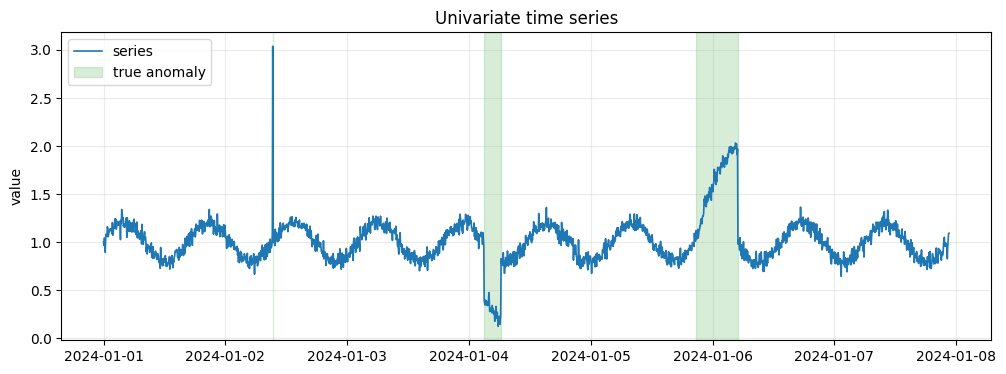

In [12]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(series.index, series.values, color='tab:blue', linewidth=1.2, label='series')

for i, (start, end) in enumerate(truth_ranges):
    ax.axvspan(start, end, color='tab:green', alpha=0.18, label='true anomaly' if i == 0 else None)

ax.set_title('Univariate time series')
ax.set_ylabel('value')
ax.grid(alpha=0.25)
ax.legend(loc='upper left')
plt.show()


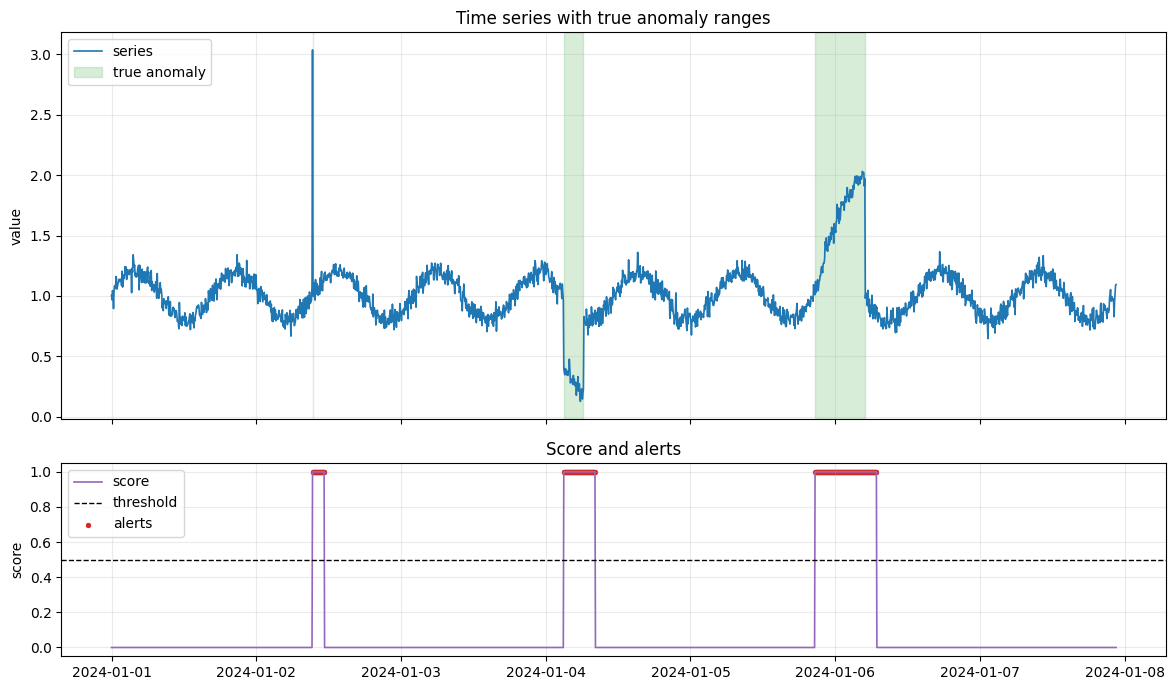

In [13]:
def plot_series_with_score(
    series: pd.Series,
    scores: pd.Series,
    truth_ranges: List[Tuple[pd.Timestamp, pd.Timestamp]],
    threshold: float,
) -> pd.Series:
    scores = scores.reindex(series.index)
    alerts = scores >= threshold

    fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True, gridspec_kw={'height_ratios': [2, 1]})

    axes[0].plot(series.index, series.values, color='tab:blue', linewidth=1.2, label='series')
    for i, (start, end) in enumerate(truth_ranges):
        axes[0].axvspan(start, end, color='tab:green', alpha=0.18, label='true anomaly' if i == 0 else None)
    axes[0].set_title('Time series with true anomaly ranges')
    axes[0].set_ylabel('value')
    axes[0].grid(alpha=0.25)
    axes[0].legend(loc='upper left')

    axes[1].plot(scores.index, scores.values, color='tab:purple', linewidth=1.2, label='score')
    axes[1].axhline(threshold, color='black', linestyle='--', linewidth=1.0, label='threshold')
    axes[1].scatter(scores.index[alerts], scores[alerts], s=8, color='tab:red', label='alerts')
    axes[1].set_title('Score and alerts')
    axes[1].set_ylabel('score')
    axes[1].grid(alpha=0.25)
    axes[1].legend(loc='upper left')

    plt.tight_layout()
    plt.show()
    return alerts


# Placeholder score for plotting workflow only
score_placeholder = labels.astype(float).rolling(24, min_periods=1).max()
threshold = 0.5
alerts = plot_series_with_score(series, score_placeholder, truth_ranges, threshold)



In [14]:
def rolling_zscore(series: pd.Series, window: int = 48) -> pd.Series:
    raise NotImplementedError('Implement rolling z-score here.')


def mad_score(series: pd.Series, window: int = 48) -> pd.Series:
    raise NotImplementedError('Implement rolling MAD-based score here.')


def stl_residual_scores(series: pd.Series, period: int = 288) -> pd.Series:
    raise NotImplementedError('Implement STL residual score here.')


def cusum_scores(series: pd.Series, drift: float = 0.0) -> pd.Series:
    raise NotImplementedError('Implement CUSUM score here.')


def matrix_profile_scores(series: pd.Series, m: int = 48):
    raise NotImplementedError('Implement Matrix Profile score here.')


def dtw_template_scores(series: pd.Series, template: np.ndarray, m: int, warping_window: int) -> pd.Series:
    raise NotImplementedError('Implement DTW template score here.')


In [ ]:
def point_metrics(pred: pd.Series, truth: pd.Series) -> dict:
    pred_b = pred.astype(bool)
    truth_b = truth.astype(bool)

    tp = int((pred_b & truth_b).sum())
    fp = int((pred_b & ~truth_b).sum())
    fn = int((~pred_b & truth_b).sum())
    tn = int((~pred_b & ~truth_b).sum())

    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) else 0.0

    return {
        'tp': tp,
        'fp': fp,
        'fn': fn,
        'tn': tn,
        'precision': precision,
        'recall': recall,
        'f1': f1,
    }


def precision_at_k(scores: pd.Series, truth: pd.Series, k: int = 50) -> float:
    raise NotImplementedError('Implement DTW template score here.')


In [16]:
m = point_metrics(alerts, labels)
p_at_50 = precision_at_k(score_placeholder, labels, k=50)

print('Point metrics:', m)
print('Precision@50:', round(p_at_50, 4))


Point metrics: {'tp': 141, 'fp': 69, 'fn': 0, 'tn': 1790, 'precision': 0.6714285714285714, 'recall': 1.0, 'f1': 0.8034188034188035}
Precision@50: 0.54
